In [1]:
# Import standard libraries

import pandas as pd
import numpy as np

In [2]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Loading dataset
from ucimlrepo import fetch_ucirepo

# Fetch dataset 
solar_flare = fetch_ucirepo(id=89)

# Separate into features and targets
X = solar_flare.data.features
y = solar_flare.data.targets

In [5]:
df = pd.concat([X, y], axis=1)
df.head()

,modified Zurich class,largest spot size,spot distribution,activity,evolution,previous 24 hour flare activity,historically-complex,became complex on this pass,area,area of largest spot,common flares,moderate flares,severe flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0


In [6]:
# Basic information
df.info()

# Quick stats for numerical columns
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   modified Zurich class            1389 non-null   object
 1   largest spot size                1389 non-null   object
 2   spot distribution                1389 non-null   object
 3   activity                         1389 non-null   int64 
 4   evolution                        1389 non-null   int64 
 5   previous 24 hour flare activity  1389 non-null   int64 
 6   historically-complex             1389 non-null   int64 
 7   became complex on this pass      1389 non-null   int64 
 8   area                             1389 non-null   int64 
 9   area of largest spot             1389 non-null   int64 
 10  common flares                    1389 non-null   int64 
 11  moderate flares                  1389 non-null   int64 
 12  severe flares                    1

modified Zurich class              0
largest spot size                  0
spot distribution                  0
activity                           0
evolution                          0
previous 24 hour flare activity    0
historically-complex               0
became complex on this pass        0
area                               0
area of largest spot               0
common flares                      0
moderate flares                    0
severe flares                      0
dtype: int64

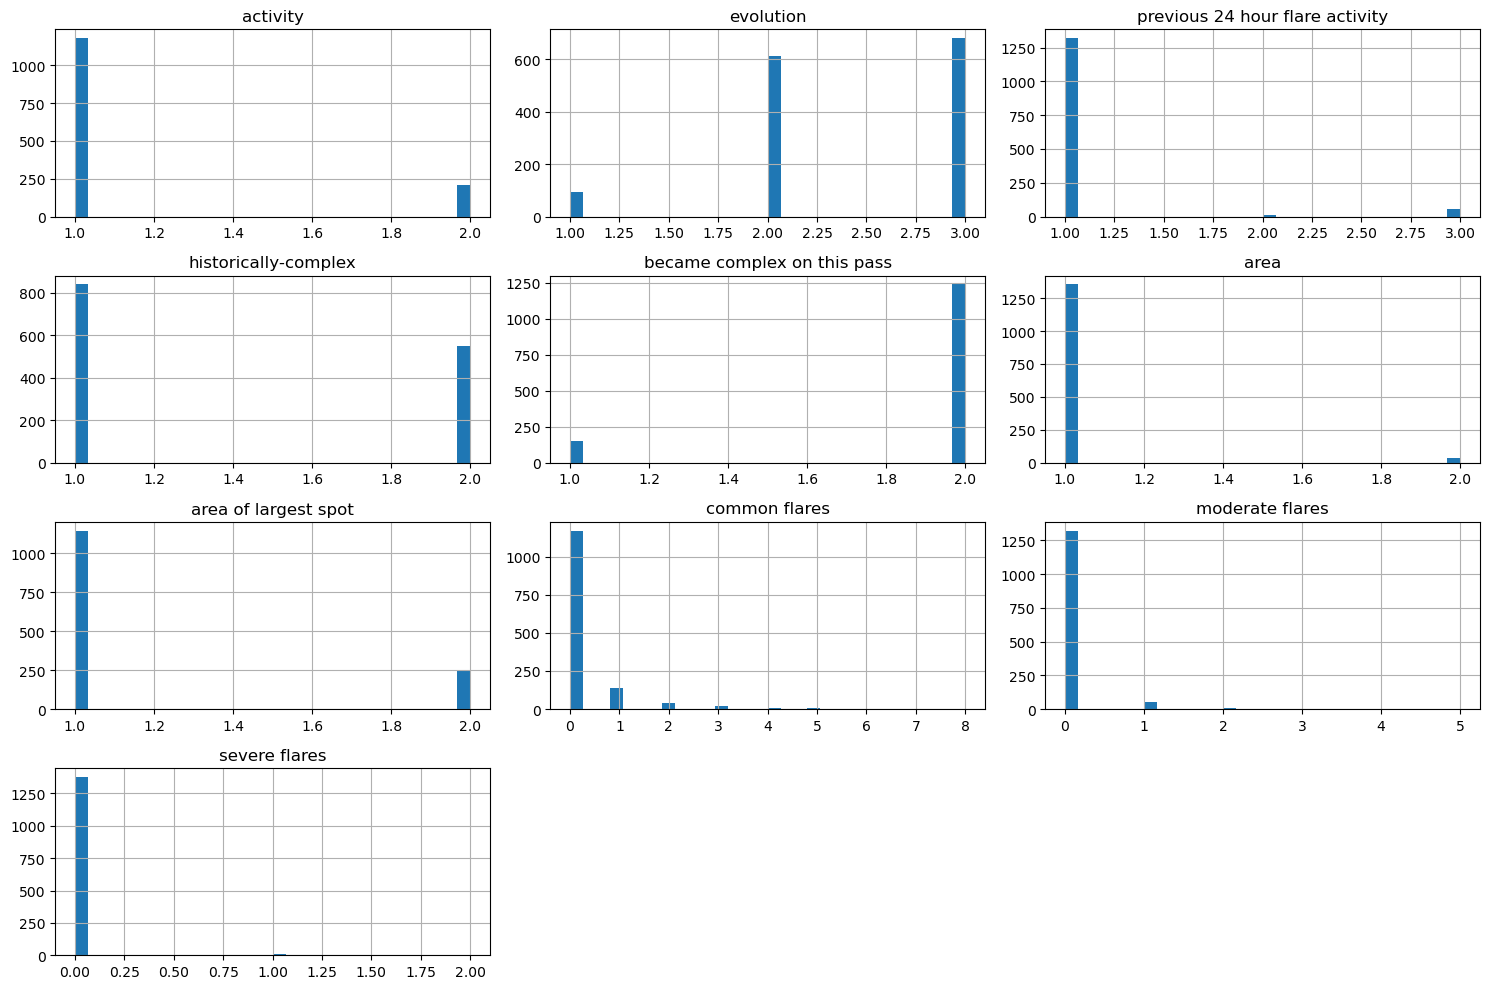

In [7]:
# View distributions as histograms
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

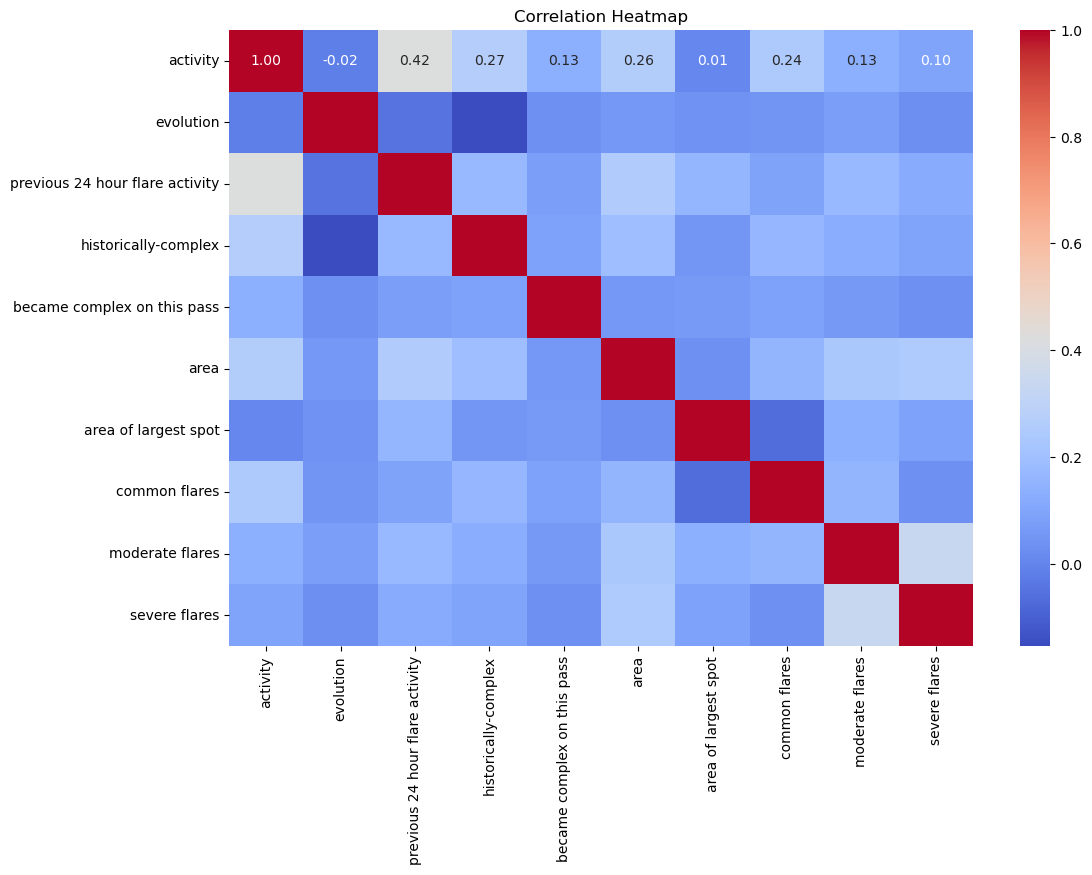

In [9]:
# correlation matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

modified Zurich class
H    396
D    327
C    287
B    212
E    116
F     51
Name: count, dtype: int64


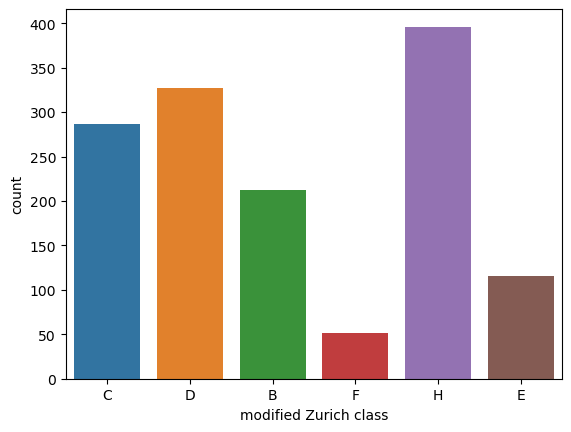

largest spot size
S    514
A    277
R    256
X    210
K     94
H     38
Name: count, dtype: int64


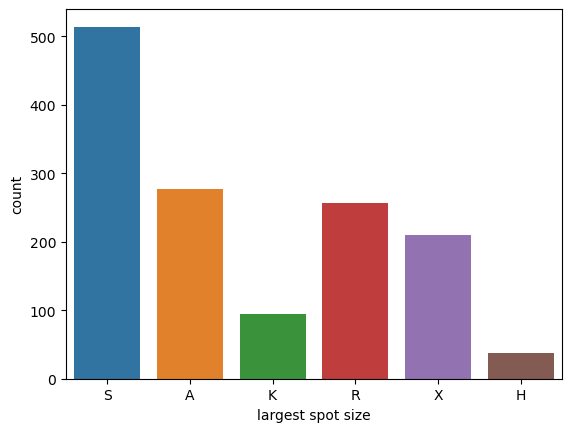

spot distribution
O    627
X    396
I    312
C     54
Name: count, dtype: int64


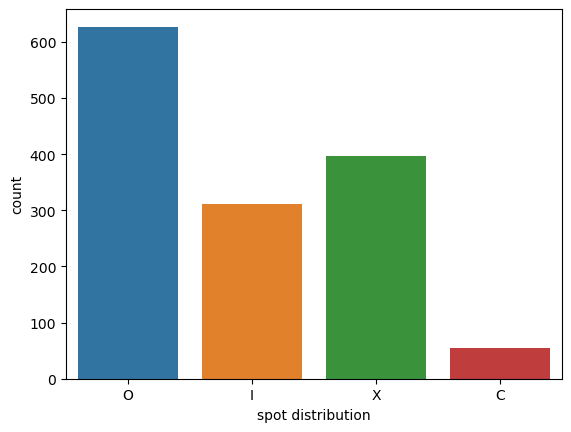

In [10]:
# overview of data based on categories
for col in ['modified Zurich class', 'largest spot size', 'spot distribution']:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.show()

common flares
0    1171
1     141
2      40
3      20
4       9
5       4
6       3
8       1
Name: count, dtype: int64


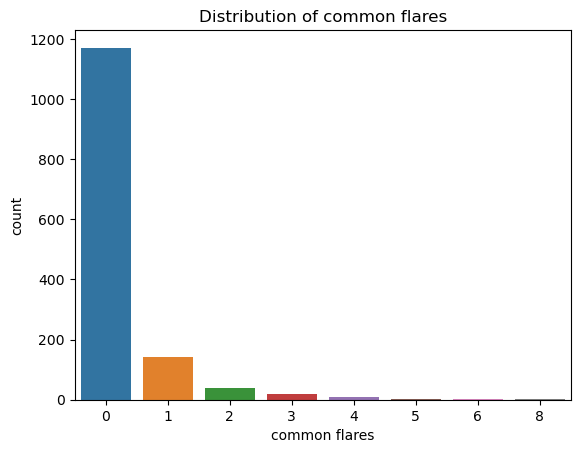

moderate flares
0    1321
1      53
2       9
4       3
3       2
5       1
Name: count, dtype: int64


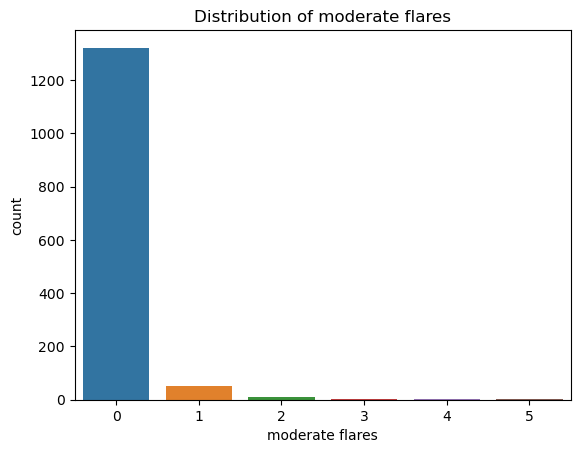

severe flares
0    1377
1      11
2       1
Name: count, dtype: int64


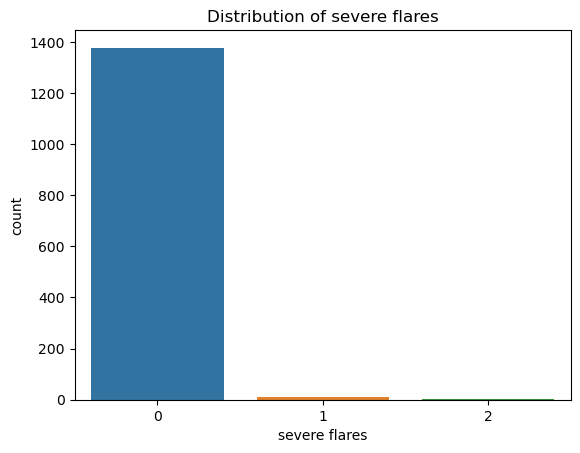

In [11]:
# exploring target variables
flare_cols = ['common flares', 'moderate flares', 'severe flares']

for col in flare_cols:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

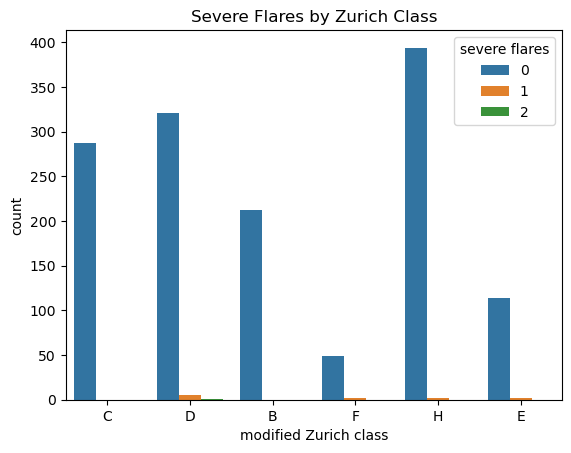

In [13]:
# display cross relationships
df['severe flares'] = df['severe flares'].astype(str)

sns.countplot(x='modified Zurich class', hue='severe flares', data=df)
plt.title("Severe Flares by Zurich Class")
plt.show()

### Hypotheses

- **H1:** Active regions with Zurich class 'D' and 'F' may exhibit a slightly higher frequency of severe flares compared to other Zurich classes, despite severe flares being rare overall.
- **H2:** The "area of largest spot" is positively correlated with the number of moderate flares, as larger sunspots could indicate stronger magnetic fields associated with moderate flaring activity.
- **H3:** Larger spot sizes and more complex spot distributions are associated with a higher number of common flares, as more active sunspot groups tend to produce frequent but less intense flares.

In [15]:
#Testing H1
from scipy.stats import chi2_contingency

# Create a contingency table
contingency = pd.crosstab(df['modified Zurich class'], df['severe flares'])

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")

Chi-squared statistic: 17.56560519150679
p-value: 0.06274853740663379


### Hypothesis 1 Conclusion:

The chi-squared test statistic is **17.57** with a **p-value of 0.0627**. Since the p-value is slightly greater than 0.05, we cannot reject the null hypothesis. This suggests that there is no relationship/correlation between the modified Zurich class and the occurrence of severe flares (at the 5% significance level). However, the p-value is close to the threshold, which means that there could be a weak association between the two variables that require further investigation.


In [16]:
#Testing H2
from scipy.stats import ttest_ind

# Split data into groups
moderate = df[df['moderate flares'] > 0]
no_moderate = df[df['moderate flares'] == 0]

# T-test
t_stat, p_val = ttest_ind(moderate['area of largest spot'], no_moderate['area of largest spot'])
print(f"T-test statistic: {t_stat}")
print(f"p-value: {p_val}")

T-test statistic: 5.970883981895568
p-value: 2.993155400374481e-09


### Hypothesis 2 Conclusion:

The t-test statistic is **5.97** with a **p-value of approximately 2.99e-09** (a lot less than 0.05). The p-value is significantly less than 0.05, therefore, we reject the null hypothesis. This implies that there is a statistically significant difference in the "area of largest spot" between regions that had moderate flares and those that did not. Essentially, this supports the hypothesis that larger sunspot areas are associated with a higher likelihood of moderate flare activity.

In [18]:
# Testing H3
from scipy.stats import f_oneway

# Correlation
groups = [df[df['largest spot size'] == cat]['common flares'] for cat in df['largest spot size'].unique()]
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat}")
print(f"p-value: {p_val}")

ANOVA F-statistic: 20.53624160712898
p-value: 7.96431191925571e-20


### Hypothesis 3 (H3) Conclusion:

The ANOVA F-statistic is **20.54** with a **p-value of approximately 7.96e-20** (extremely small and well below 0.05). Since the p-value is much less than 0.05, we reject the null hypothesis. This indicates that the "largest spot size" categories are associated with significant differences in the number of common flares.

### Final Summary & Conclusion

In this analysis, we aimed to explore relationships between sunspot activity indicators and solar flare occurrences using the Solar Flare Dataset.

#### Key Findings:

- **H1:** We investigated whether Zurich classes 'D' and 'F' are associated with a higher frequency of severe flares. The chi-squared test resulted in a **p-value of 0.0627**, which is slightly above the 0.05 threshold. This displays no statistically significant association between Zurich classes and severe flares at the 5% significance level. However, the result is borderline and require further investigation.

- **H2:** We tested whether larger sunspot areas are linked to moderate flares. The t-test yielded a **p-value of approximately 2.99e-09**, illustrating a strong, statistically significant difference in "area of largest spot" between regions with and without moderate flares. This supports our hypothesis that larger sunspot areas are associated with moderate flare activity.

- **H3:** We explored whether spot size categories are associated with common flare counts. The ANOVA test produced a **p-value of approximately 7.96e-20**. This is strong evidence indicating significant differences in common flare counts across different spot size categories. This supports our hypothesis that larger and more complex spot sizes are associated with a higher number of common flares.

#### Conclusion:

While severe flares are not prevalent in this dataset, we found significant relationships between sunspot size and both moderate and common flare activity. These findings highlight how features like sunspot area and spot size categories are significat indicators of flare activity levels. 